### 2D line attractor system anaylsis

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot_flow_field(a, b, v_0=0, x_0=0, nonlinearity='relu'):
    # System parameters
    tau = 1.0
    W = np.array([[a, b],
                  [b,  a]])
    v = np.ones((2)) * v_0
    x0 = np.ones((2)) * x_0
    
    # ReLU function
    def relu(x):
        return np.maximum(0, x)
    
    # Define the system dynamics
    def h_dot(h):
        if nonlinearity == 'relu':
            return (W @ relu(h - v) - h + x0) / tau
        elif nonlinearity == 'tanh':
            return (W @ np.tanh(relu(h - v)) - h + x0) / tau
        else:
            raise NotImplementedError('Nonlinearity not found')
    
    # Grid for plotting
    x_vals = np.linspace(-1, 2.5, 25)
    y_vals = np.linspace(-1, 2.5, 25)
    X, Y = np.meshgrid(x_vals, y_vals)
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    # Evaluate vector field
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            h = np.array([X[i, j], Y[i, j]])
            dh = h_dot(h)
            U[i, j], V[i, j] = dh
    
    # Normalize vectors for quiver
    magnitude = np.sqrt(U**2 + V**2)
    U_norm = U / (magnitude + 1e-6)
    V_norm = V / (magnitude + 1e-6)
    
    # Plot
    scale = 1.5
    fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 3 * scale))
    m = axs.quiver(X, Y, U_norm, V_norm, magnitude, cmap='viridis')
    axs.set_xlabel('$h_1$')
    axs.set_ylabel('$h_2$')
    axs.set_title('Flow Field for $\dot{h} = \\frac{1}{\\tau}(W [h - v]^+ - h + x_0)$')
    axs.axvline(v[0], color='gray', linestyle='--', alpha=0.5)
    axs.axhline(v[1], color='gray', linestyle='--', alpha=0.5)
    fig.colorbar(m, label='Speed')
    axs.grid(True)
    axs.axis('equal')
    fig.show()

<>:47: SyntaxWarning: invalid escape sequence '\d'
<>:47: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1652989/2700939273.py:47: SyntaxWarning: invalid escape sequence '\d'
  axs.set_title('Flow Field for $\dot{h} = \\frac{1}{\\tau}(W [h - v]^+ - h + x_0)$')


### When are line attractors possible in networks of 2 units?
Aim: investigate systems of 2 neurons with symmetric weight matrices that can behave like line attractors.

I'll begin with ReLU units.

#### Two self-connected ReLU units

Dynamics obey:

$$\dot{h} = W [h - v]^+ - h + x_0$$

where

$$
W = \begin{pmatrix}
a & b \\
b & a
\end{pmatrix}
$$

and $h$ is the hidden field, $v$ is the threshold, and $x_0$ is external input.

#### Self-connected but disconnected neurons

$$
W = \begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
$$

with $x_0 = 0$, $v = 0$.

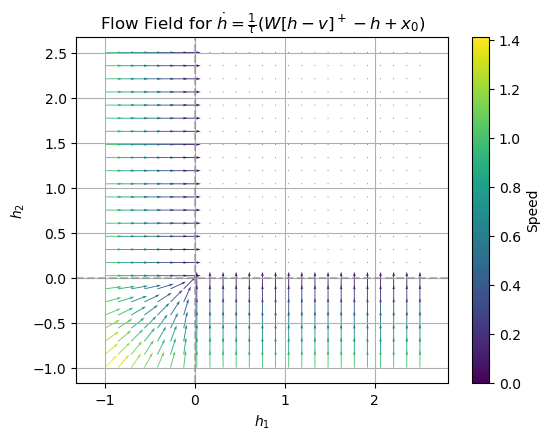

In [7]:
plot_flow_field(1, 0, x_0=0)

#### Line attractor where units trade activity level
$0 < a < 1$, $b = a - 1$, $x_0 > 0$

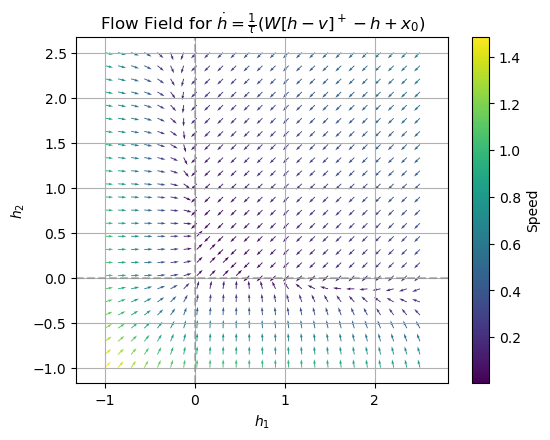

In [5]:
a = 0.9
plot_flow_field(a, a-1, x_0=0.05)


$$
W = \begin{pmatrix}
0.9 & -0.1 \\
-0.1 & 0.9
\end{pmatrix}
$$

$$x_0 = 0.1$$


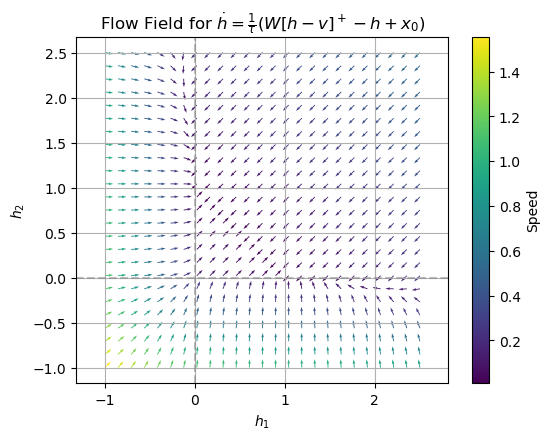

In [4]:
a = 0.9
plot_flow_field(a, a-1, x_0=0.1)


$$
W = \begin{pmatrix}
0.9 & -0.2 \\
-0.2 & 0.9
\end{pmatrix}
$$

$$x_0 = 0.1$$

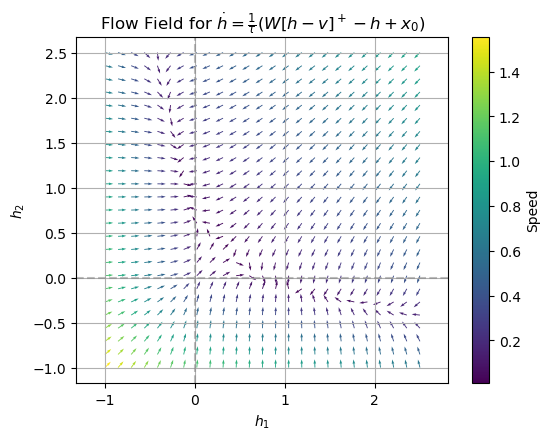

In [3]:
a = 0.9
plot_flow_field(a, a-1.1, x_0=0.1)


$$
W = \begin{pmatrix}
0.9 & 0 \\
0 & 0.9
\end{pmatrix}
$$

$$x_0 = 0.1$$

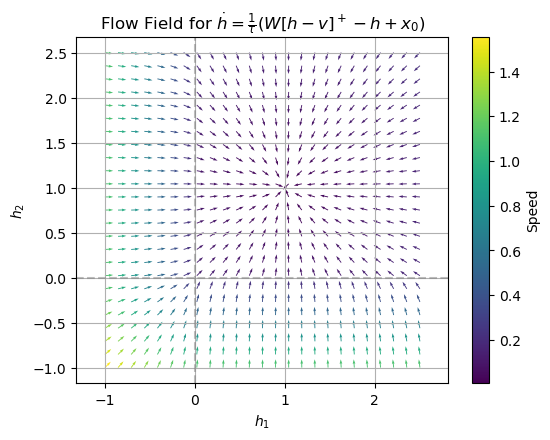

In [5]:
a = 0.9
plot_flow_field(a, a-0.9, x_0=0.1)

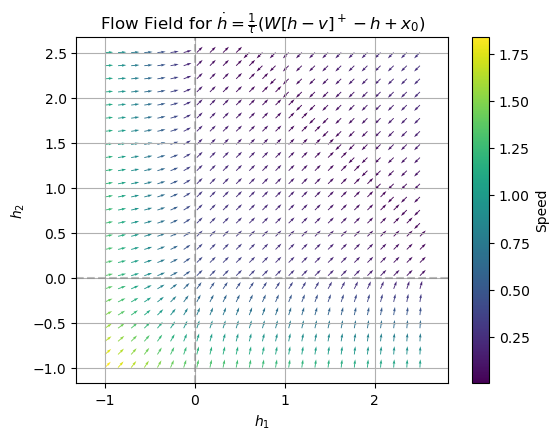

In [7]:
a = 0.9
plot_flow_field(a, a-1, x_0=0.3)

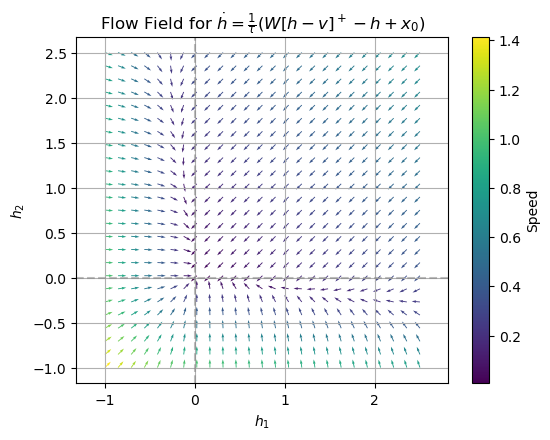

In [4]:
a = 0.9
plot_flow_field(a, a-1, x_0=0)

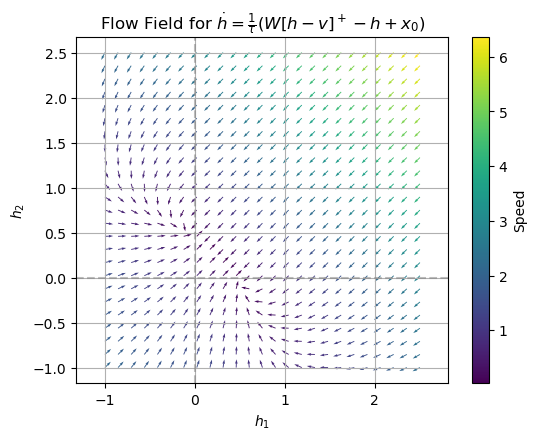

In [23]:
plot_flow_field(0, -1, x_0=0.5)

#### Ramping solution
$a = 0$, $b = 1$, $x_0 = 0$

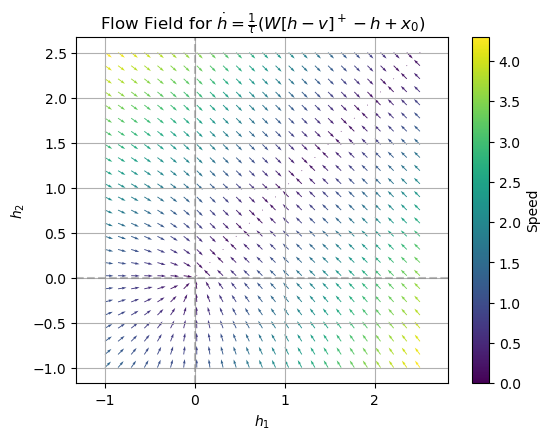

In [8]:
plot_flow_field(0, 1, x_0=0)

#### Network with tanh nonlinearity can approximate seesaw line attractor solution

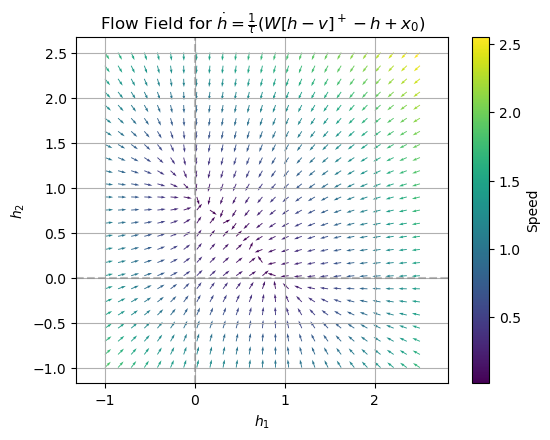

In [40]:
plot_flow_field(0.8, -0.4, x_0=0.3, nonlinearity='tanh')

#### With $x_0 = 0$, only saddle dynamics are possible for activity that trades off

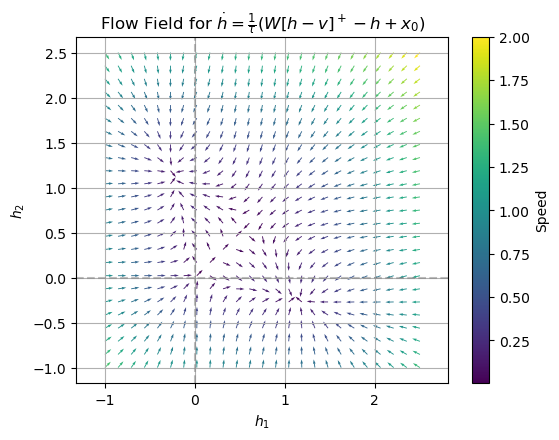

In [48]:
plot_flow_field(1.4, -0.3, x_0=0, nonlinearity='tanh')